# IBM Telco Customer Churn: Exploratory Data Analysis

## Project Overview

Customer churn is a major business concern for telecommunications companies because acquiring new customers is often more costly than retaining existing ones. This exploratory data analysis examines customer demographics, account characteristics, service usage, billing behavior, and financial attributes to identify patterns associated with churn.

The analysis uses the cleaned IBM Telco Customer Churn dataset containing 7,043 customer records. Data preparation was completed separately in `01_data_cleaning.ipynb`, allowing this notebook to focus on analytical exploration, visualization, and business interpretation.

## Business Objective

The primary objective is to identify customer characteristics and service patterns associated with elevated churn risk. The results will support the development of targeted retention strategies and an executive Power BI dashboard.

## Business Questions

1. What is the overall customer churn rate?
2. How does churn vary across contract types and tenure groups?
3. Which internet and support services are associated with customer retention?
4. How do payment method and billing preferences relate to churn?
5. Are customers with higher monthly charges more likely to churn?
6. Which demographic and household segments experience the highest churn?
7. What combination of characteristics defines the highest-risk customer segments?

## Analysis Roadmap

1. Data loading and validation
2. Customer and churn overview
3. Demographic analysis
4. Contract and tenure analysis
5. Internet and support service analysis
6. Billing and payment analysis
7. Financial analysis
8. Multivariate and correlation analysis
9. Key business insights

In [77]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Visualization configuration
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.05
)

RANDOM_STATE = 42

## 1. Data Loading and Validation

The exploratory analysis uses the processed dataset produced by the data-cleaning notebook. Loading the processed file prevents duplication of cleaning logic and maintains a clear analytical workflow:

**Raw data → Data cleaning → Processed data → Exploratory analysis**

In [78]:
DATA_PATH = Path("../data/processed/telco_churn_clean.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset was not found at: {DATA_PATH.resolve()}"
    )

telco_churn = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {telco_churn.shape[0]:,}")
print(f"Columns: {telco_churn.shape[1]}")

telco_churn.head()

Dataset loaded successfully.
Rows: 7,043
Columns: 21


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 months
1,Male,0,No,No,34,Yes,No,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,"1,889.50",0,25-48 months
2,Male,0,No,No,2,Yes,No,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 months
3,Male,0,No,No,45,No,No phone service,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,"1,840.75",0,25-48 months
4,Female,0,No,No,2,Yes,No,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 months


In [79]:
telco_churn.columns = (
    telco_churn.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

telco_churn.columns.tolist()

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn',
 'tenure_group']

Standardize column names

In [80]:
telco_churn.columns = (
    telco_churn.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

telco_churn.columns.tolist()

['gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn',
 'tenure_group']

### Initial Dataset Validation

The following checks confirm that the processed dataset has the expected dimensions, column structure, data types, and completeness before analysis begins.

In [81]:
dataset_summary = pd.DataFrame(
    {
        "Metric": [
            "Number of rows",
            "Number of columns",
            "Duplicate rows",
            "Missing values"
        ],
        "Value": [
            telco_churn.shape[0],
            telco_churn.shape[1],
            telco_churn.duplicated().sum(),
            telco_churn.isna().sum().sum()
        ]
    }
)

dataset_summary

,Metric,Value
0,Number of rows,7043
1,Number of columns,21
2,Duplicate rows,22
3,Missing values,0


In [82]:
telco_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   int64  
 9   onlinebackup      7043 non-null   int64  
 10  deviceprotection  7043 non-null   int64  
 11  techsupport       7043 non-null   int64  
 12  streamingtv       7043 non-null   int64  
 13  streamingmovies   7043 non-null   int64  
 14  contract          7043 non-null   object 
 15  paperlessbilling  7043 non-null   object 
 16  paymentmethod     7043 non-null   object 


Review column-level quality

In [83]:
column_profile = pd.DataFrame(
    {
        "data_type": telco_churn.dtypes.astype(str),
        "missing_values": telco_churn.isna().sum(),
        "missing_pct": (
            telco_churn.isna().mean() * 100
        ).round(2),
        "unique_values": telco_churn.nunique()
    }
).sort_values(
    by=["missing_values", "unique_values"],
    ascending=[False, True]
)

column_profile

,data_type,missing_values,missing_pct,unique_values
gender,object,0,0.00,2
seniorcitizen,int64,0,0.00,2
partner,object,0,0.00,2
dependents,object,0,0.00,2
phoneservice,object,0,0.00,2
onlinesecurity,int64,0,0.00,2
onlinebackup,int64,0,0.00,2
deviceprotection,int64,0,0.00,2
techsupport,int64,0,0.00,2
streamingtv,int64,0,0.00,2


Validate the churn target

In [84]:
telco_churn["churn"].value_counts(dropna=False).sort_index()

churn
0    5174
1    1869
Name: count, dtype: int64

In [85]:
invalid_churn_values = set(telco_churn["churn"].dropna().unique()) - {0, 1}

if invalid_churn_values:
    raise ValueError(
        f"Unexpected churn values found: {invalid_churn_values}"
    )

overall_churn_rate = telco_churn["churn"].mean()

print(f"Overall churn rate: {overall_churn_rate:.2%}")

Overall churn rate: 26.54%


### Validation Summary

The processed dataset contains 7,043 customer records and is ready for exploratory analysis. The customer identifier was removed during data preparation because it does not provide analytical value. `TotalCharges` was converted to a numeric field, binary service and churn variables were encoded, and a tenure-group feature was created.

Repeated combinations of customer characteristics may still exist because different customers can share identical demographic, service, and billing attributes. These records are retained because the original dataset contained no duplicate customer identifiers or complete duplicate rows.

## 2. Customer and Churn Overview

This section establishes the overall size of the customer base and evaluates the distribution of churned and retained customers. These metrics provide the baseline for all later segment-level comparisons.

KPI summary

In [86]:
total_customers = len(telco_churn)
churned_customers = telco_churn["churn"].sum()
retained_customers = total_customers - churned_customers

churn_rate = telco_churn["churn"].mean()
retention_rate = 1 - churn_rate

customer_kpis = pd.DataFrame(
    {
        "KPI": [
            "Total Customers",
            "Churned Customers",
            "Retained Customers",
            "Churn Rate",
            "Retention Rate"
        ],
        "Value": [
            f"{total_customers:,}",
            f"{churned_customers:,}",
            f"{retained_customers:,}",
            f"{churn_rate:.2%}",
            f"{retention_rate:.2%}"
        ]
    }
)

customer_kpis

,KPI,Value
0,Total Customers,"7,043"
1,Churned Customers,"1,869"
2,Retained Customers,"5,174"
3,Churn Rate,26.54%
4,Retention Rate,73.46%


Churn distribution table

In [87]:
churn_distribution = (
    telco_churn["churn"]
    .value_counts()
    .rename_axis("churn")
    .reset_index(name="customer_count")
    .sort_values("churn")
)

churn_distribution["churn_status"] = churn_distribution["churn"].map(
    {
        0: "Retained",
        1: "Churned"
    }
)

churn_distribution["customer_percentage"] = (
    churn_distribution["customer_count"]
    / churn_distribution["customer_count"].sum()
    * 100
).round(2)

churn_distribution[
    [
        "churn_status",
        "customer_count",
        "customer_percentage"
    ]
]

,churn_status,customer_count,customer_percentage
0,Retained,5174,73.46
1,Churned,1869,26.54


### Customer Churn Distribution

The following chart compares the number and percentage of retained and churned customers.

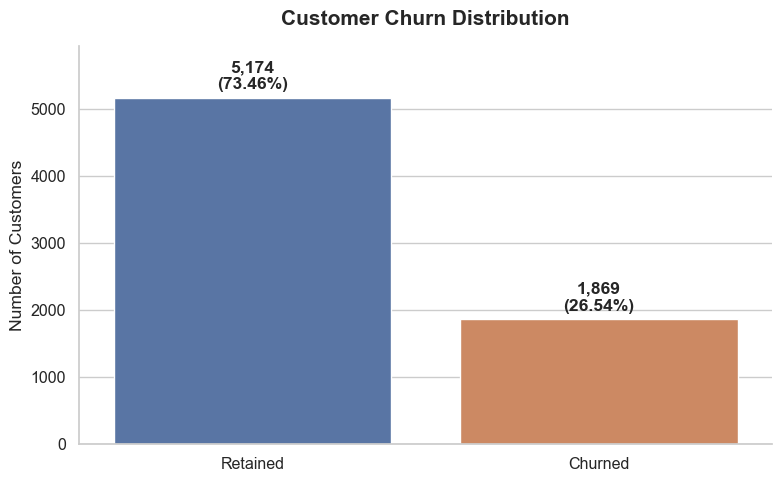

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))

churn_plot = sns.barplot(
    data=churn_distribution,
    x="churn_status",
    y="customer_count",
    hue="churn_status",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Distribution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Number of Customers")

ax.set_ylim(
    0,
    churn_distribution["customer_count"].max() * 1.15
)

for index, row in churn_distribution.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["customer_count"] + 80,
        (
            f'{row["customer_count"]:,}\n'
            f'({row["customer_percentage"]:.2f}%)'
        ),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

The dataset contains 7,043 customers, of whom 1,869 churned and 5,174 were retained. The overall churn rate is **26.54%**, meaning approximately one out of every four customers left the company.

The target variable is moderately imbalanced because retained customers represent 73.46% of the dataset. This imbalance is not severe enough to prevent exploratory analysis, but it should be considered later when conducting statistical analysis or building predictive models.

Churn status helper column

In [89]:
telco_churn["churn_status"] = telco_churn["churn"].map(
    {
        0: "Retained",
        1: "Churned"
    }
)

telco_churn[["churn", "churn_status"]].head()

,churn,churn_status
0,0,Retained
1,0,Retained
2,1,Churned
3,0,Retained
4,1,Churned


### Numeric Feature Summary

The main continuous customer measures are tenure, monthly charges, and total charges. Their distributions help describe the typical customer relationship and financial profile.

In [90]:
numeric_columns = [
    "tenure",
    "monthlycharges",
    "totalcharges"
]

numeric_summary = (
    telco_churn[numeric_columns]
    .describe()
    .T
    .rename(
        columns={
            "count": "Count",
            "mean": "Mean",
            "std": "Standard Deviation",
            "min": "Minimum",
            "25%": "25th Percentile",
            "50%": "Median",
            "75%": "75th Percentile",
            "max": "Maximum"
        }
    )
)

numeric_summary

,Count,Mean,Standard Deviation,Minimum,25th Percentile,Median,75th Percentile,Maximum
tenure,"7,043.00",32.37,24.56,0.00,9.00,29.00,55.00,72.00
monthlycharges,"7,043.00",64.76,30.09,18.25,35.50,70.35,89.85,118.75
totalcharges,"7,043.00","2,279.73","2,266.79",0.00,398.55,"1,394.55","3,786.60","8,684.80"


### Initial Numeric Observations

Customer tenure varies from newly enrolled customers to customers with six years of service. Monthly and total charges also vary substantially, reflecting differences in service packages, contract length, and customer tenure.

Because `TotalCharges` accumulates over time, it is expected to be strongly related to tenure. Later sections will compare these financial measures between retained and churned customers.

## 3. Demographic Analysis

This section evaluates whether customer demographics and household characteristics are associated with churn. The analysis focuses on gender, senior-citizen status, partner status, and dependent status.

In [91]:
telco_churn["senior_status"] = telco_churn["seniorcitizen"].map(
    {
        0: "Non-Senior",
        1: "Senior"
    }
)

demographic_columns = [
    "gender",
    "senior_status",
    "partner",
    "dependents"
]

telco_churn[demographic_columns].head()

,gender,senior_status,partner,dependents
0,Female,Non-Senior,Yes,No
1,Male,Non-Senior,No,No
2,Male,Non-Senior,No,No
3,Male,Non-Senior,No,No
4,Female,Non-Senior,No,No


Reusable churn-summary function

In [92]:
def summarize_churn_by_category(
    dataframe: pd.DataFrame,
    category_column: str
) -> pd.DataFrame:
    """
    Calculate customer count, churned customers, and churn rate
    for each category within a selected feature.
    """
    summary = (
        dataframe
        .groupby(category_column, observed=False)
        .agg(
            customer_count=("churn", "size"),
            churned_customers=("churn", "sum"),
            churn_rate=("churn", "mean")
        )
        .reset_index()
    )

    summary["churn_rate_pct"] = (
        summary["churn_rate"] * 100
    ).round(2)

    return summary.sort_values(
        "churn_rate",
        ascending=False
    )

### Churn by Gender

Gender is evaluated to determine whether churn differs meaningfully between male and female customers.

In [93]:
gender_churn = summarize_churn_by_category(
    telco_churn,
    "gender"
)

gender_churn

,gender,customer_count,churned_customers,churn_rate,churn_rate_pct
0,Female,3488,939,0.27,26.92
1,Male,3555,930,0.26,26.16


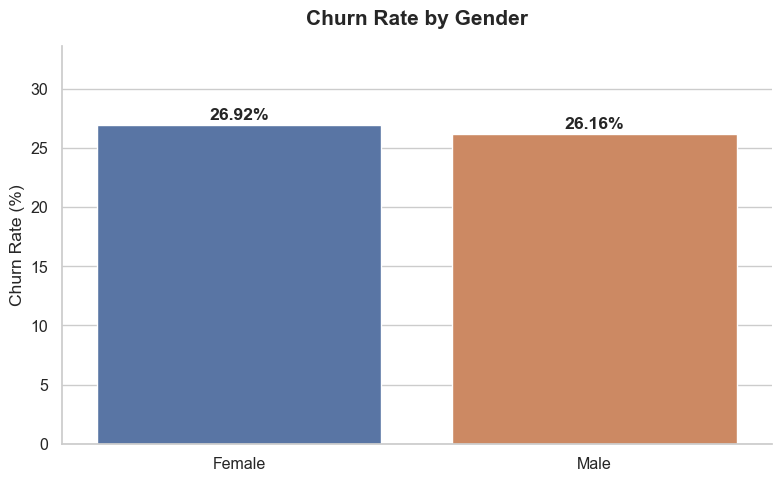

In [94]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=gender_churn,
    x="gender",
    y="churn_rate_pct",
    hue="gender",
    legend=False,
    ax=ax
)

ax.set_title(
    "Churn Rate by Gender",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, gender_churn["churn_rate_pct"].max() * 1.25)

for index, row in gender_churn.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["churn_rate_pct"] + 0.5,
        f'{row["churn_rate_pct"]:.2f}%',
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Churn rates are broadly similar across gender groups. Gender does not appear to be a major standalone driver of customer churn and is therefore less useful for prioritizing retention campaigns than contract, tenure, service, or billing characteristics.

### Churn by Senior-Citizen Status

Senior-citizen status is analyzed to determine whether older customers experience different retention outcomes.

In [95]:
senior_churn = summarize_churn_by_category(
    telco_churn,
    "senior_status"
)

senior_churn

,senior_status,customer_count,churned_customers,churn_rate,churn_rate_pct
1,Senior,1142,476,0.42,41.68
0,Non-Senior,5901,1393,0.24,23.61


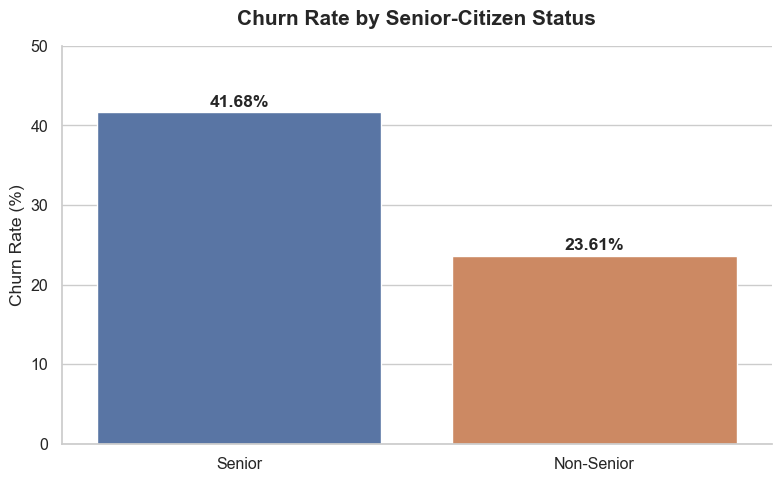

In [96]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=senior_churn,
    x="senior_status",
    y="churn_rate_pct",
    hue="senior_status",
    legend=False,
    ax=ax
)

ax.set_title(
    "Churn Rate by Senior-Citizen Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, senior_churn["churn_rate_pct"].max() * 1.2)

for index, row in senior_churn.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["churn_rate_pct"] + 0.7,
        f'{row["churn_rate_pct"]:.2f}%',
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Senior customers show a substantially higher churn rate than non-senior customers. The SQL analysis found churn rates of approximately **41.68% for senior customers** compared with **23.61% for non-senior customers**.

This suggests that senior customers may face greater service, pricing, support, or usability challenges. However, senior status should not be interpreted as a direct cause of churn. It may interact with contract type, payment method, service package, and support-service adoption.

### Churn by Partner Status

Partner status is used as a household indicator to evaluate whether customers living with a partner demonstrate stronger retention.

In [97]:
partner_churn = summarize_churn_by_category(
    telco_churn,
    "partner"
)

partner_churn

,partner,customer_count,churned_customers,churn_rate,churn_rate_pct
0,No,3641,1200,0.33,32.96
1,Yes,3402,669,0.20,19.66


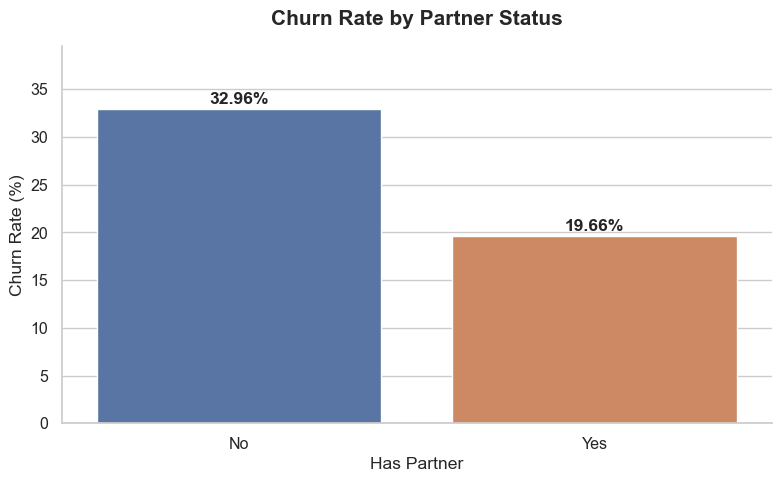

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=partner_churn,
    x="partner",
    y="churn_rate_pct",
    hue="partner",
    legend=False,
    ax=ax
)

ax.set_title(
    "Churn Rate by Partner Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Has Partner")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, partner_churn["churn_rate_pct"].max() * 1.2)

for index, row in partner_churn.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["churn_rate_pct"] + 0.5,
        f'{row["churn_rate_pct"]:.2f}%',
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Customers without a partner generally experience higher churn than customers with a partner. This may indicate that customers in multi-person households have greater service dependence or use a broader combination of telecommunications services.

### Churn by Dependent Status

Dependent status provides another view of household structure and may reflect differences in service stability and customer needs.

In [99]:
dependents_churn = summarize_churn_by_category(
    telco_churn,
    "dependents"
)

dependents_churn

,dependents,customer_count,churned_customers,churn_rate,churn_rate_pct
0,No,4933,1543,0.31,31.28
1,Yes,2110,326,0.15,15.45


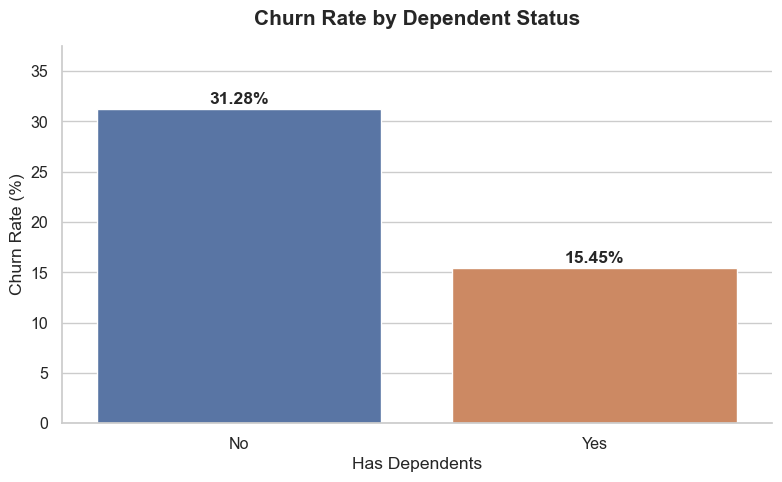

In [100]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=dependents_churn,
    x="dependents",
    y="churn_rate_pct",
    hue="dependents",
    legend=False,
    ax=ax
)

ax.set_title(
    "Churn Rate by Dependent Status",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Has Dependents")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, dependents_churn["churn_rate_pct"].max() * 1.2)

for index, row in dependents_churn.reset_index(drop=True).iterrows():
    ax.text(
        index,
        row["churn_rate_pct"] + 0.5,
        f'{row["churn_rate_pct"]:.2f}%',
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Customers without dependents generally churn more frequently than customers with dependents. Household stability may therefore be associated with stronger retention, although this relationship should be evaluated together with partner status and other account characteristics.

### Combined Household Segment Analysis

Partner and dependent status are combined to evaluate churn across four household profiles.

In [101]:
telco_churn["household_segment"] = (
    "Partner: " + telco_churn["partner"]
    + " | Dependents: " + telco_churn["dependents"]
)

household_churn = summarize_churn_by_category(
    telco_churn,
    "household_segment"
)

household_churn

,household_segment,customer_count,churned_customers,churn_rate,churn_rate_pct
0,Partner: No | Dependents: No,3280,1123,0.34,34.24
2,Partner: Yes | Dependents: No,1653,420,0.25,25.41
1,Partner: No | Dependents: Yes,361,77,0.21,21.33
3,Partner: Yes | Dependents: Yes,1749,249,0.14,14.24


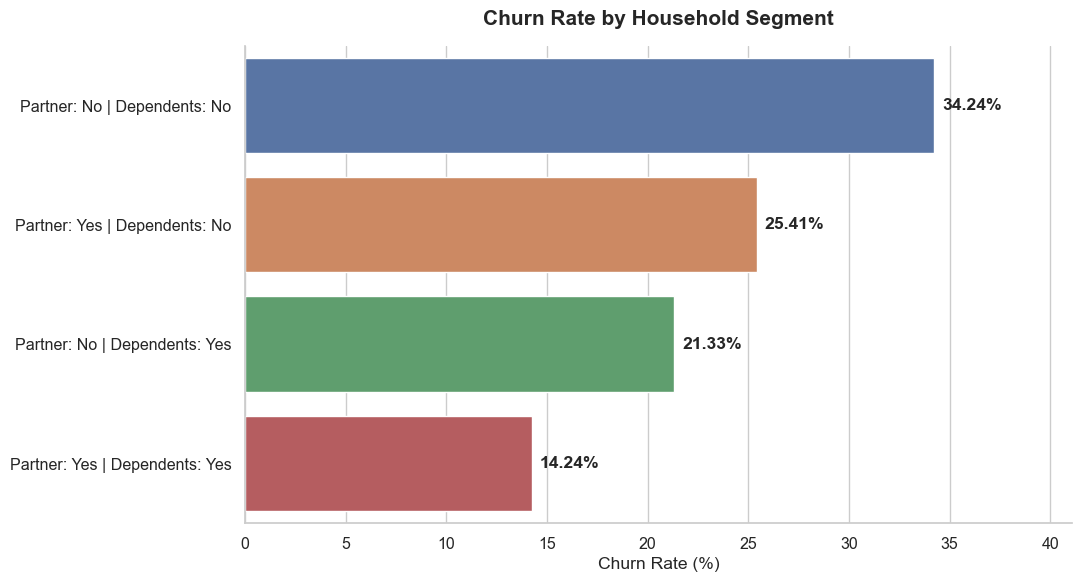

In [102]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=household_churn,
    y="household_segment",
    x="churn_rate_pct",
    hue="household_segment",
    legend=False,
    ax=ax
)

ax.set_title(
    "Churn Rate by Household Segment",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, household_churn["churn_rate_pct"].max() * 1.2)

for index, row in household_churn.reset_index(drop=True).iterrows():
    ax.text(
        row["churn_rate_pct"] + 0.4,
        index,
        f'{row["churn_rate_pct"]:.2f}%',
        va="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Household structure shows a clear relationship with retention:

- Customers with neither a partner nor dependents have the highest churn rate, approximately **34.24%**.
- Customers with a partner but no dependents have a churn rate of approximately **25.41%**.
- Customers without a partner but with dependents have a churn rate of approximately **21.33%**.
- Customers with both a partner and dependents have the lowest churn rate, approximately **14.24%**.

These results suggest that customers in more established household structures tend to remain with the company longer. Household characteristics may help improve segmentation, but they should be combined with stronger behavioral predictors such as tenure, contract, and service usage.

### Demographic Analysis Summary

Demographic variables provide useful context but do not carry equal predictive value. Gender shows little meaningful churn variation, while senior status and household structure show stronger differences.

Senior customers and customers without a partner or dependents represent higher-risk demographic segments. However, these findings should be used carefully and combined with account behavior rather than used as the sole basis for retention decisions.

## 4. Contract and Tenure Analysis

Customer tenure and contract type are among the strongest indicators of customer retention. This section investigates how customer commitment changes over time and evaluates the relationship between contract duration and churn.

Understanding these patterns helps identify when customers are most likely to leave and which contract structures provide the greatest protection against churn.

### Churn by Contract Type

Contract length is expected to have a significant impact on customer retention because longer commitments generally increase customer stability.

In [103]:
contract_churn = summarize_churn_by_category(
    telco_churn,
    "contract"
)

contract_churn

,contract,customer_count,churned_customers,churn_rate,churn_rate_pct
0,Month-to-month,3875,1655,0.43,42.71
1,One year,1473,166,0.11,11.27
2,Two year,1695,48,0.03,2.83


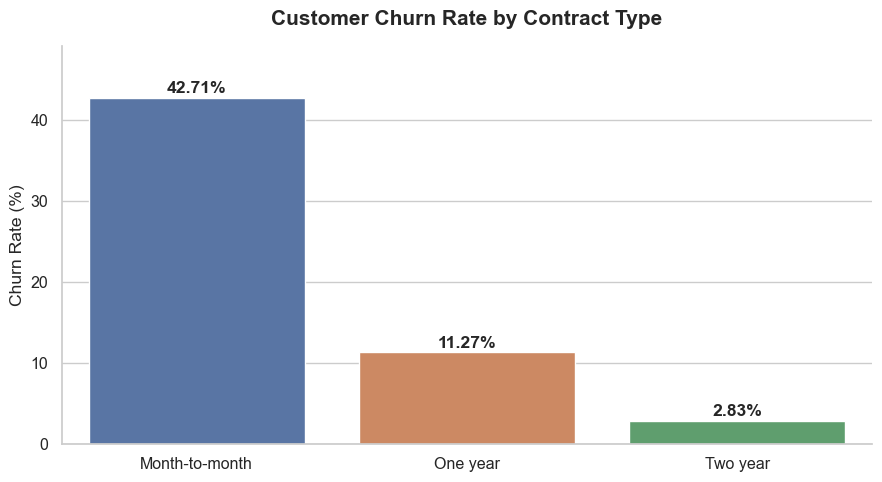

In [104]:
fig, ax = plt.subplots(figsize=(9,5))

sns.barplot(
    data=contract_churn,
    x="contract",
    y="churn_rate_pct",
    hue="contract",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Rate by Contract Type",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")

ax.set_ylim(
    0,
    contract_churn["churn_rate_pct"].max()*1.15
)

for i,row in contract_churn.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["churn_rate_pct"]+0.6,
        f"{row['churn_rate_pct']:.2f}%",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Contract type is the strongest categorical predictor of churn observed in the analysis.

Customers with month-to-month contracts experience a churn rate of approximately **42.71%**, compared with **11.27%** for one-year contracts and only **2.83%** for two-year contracts.

Long-term contracts appear to substantially improve customer retention by increasing customer commitment and reducing switching behavior. Encouraging eligible customers to transition from month-to-month plans to annual contracts could significantly reduce churn.

### Customer Distribution Across Contract Types

Before interpreting churn rates, it is useful to understand how customers are distributed across the available contract options.

In [105]:
contract_distribution = (
    telco_churn["contract"]
    .value_counts()
    .rename_axis("contract")
    .reset_index(name="customer_count")
)

contract_distribution["percentage"] = (
    contract_distribution["customer_count"]
    / contract_distribution["customer_count"].sum()
    *100
).round(2)

contract_distribution

,contract,customer_count,percentage
0,Month-to-month,3875,55.02
1,Two year,1695,24.07
2,One year,1473,20.91


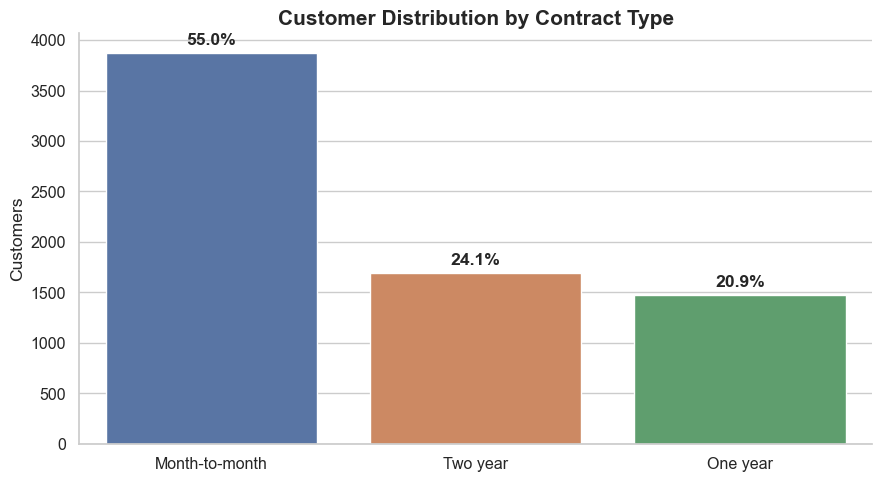

In [106]:
fig, ax = plt.subplots(figsize=(9,5))

sns.barplot(
    data=contract_distribution,
    x="contract",
    y="customer_count",
    hue="contract",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Distribution by Contract Type",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Customers")

for i,row in contract_distribution.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["customer_count"]+80,
        f"{row['percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Churn by Customer Tenure

Customer tenure measures the length of the customer relationship. Newer customers are generally expected to exhibit higher churn than long-standing customers.

In [107]:
tenure_churn = summarize_churn_by_category(
    telco_churn,
    "tenure_group"
)

tenure_churn

,tenure_group,customer_count,churned_customers,churn_rate,churn_rate_pct
0,0-12 months,2186,1037,0.47,47.44
1,13-24 months,1024,294,0.29,28.71
2,25-48 months,1594,325,0.20,20.39
3,49-72 months,2239,213,0.10,9.51


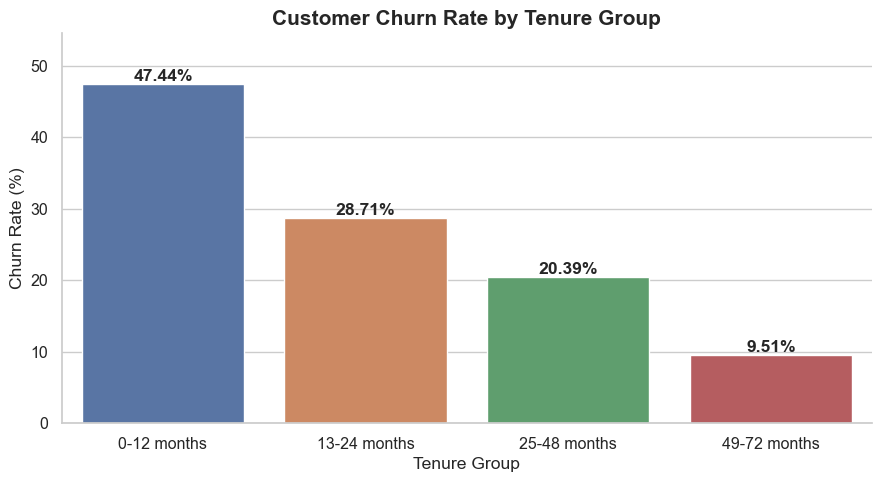

In [108]:
fig, ax = plt.subplots(figsize=(9,5))

sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="churn_rate_pct",
    hue="tenure_group",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Rate by Tenure Group",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Tenure Group")
ax.set_ylabel("Churn Rate (%)")

ax.set_ylim(
    0,
    tenure_churn["churn_rate_pct"].max()*1.15
)

for i,row in tenure_churn.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["churn_rate_pct"]+0.5,
        f"{row['churn_rate_pct']:.2f}%",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Customer churn decreases steadily as tenure increases.

Customers within their first year exhibit the highest churn rate, approximately **47.44%**, while customers with more than four years of service experience substantially lower churn.

This pattern suggests that the first twelve months represent the most critical period for customer retention. Improving onboarding, customer engagement, and early support may significantly reduce overall churn.

### Monthly Charges Across Contract Types

Contract length may influence monthly pricing. Comparing charge distributions helps determine whether pricing differences contribute to churn.

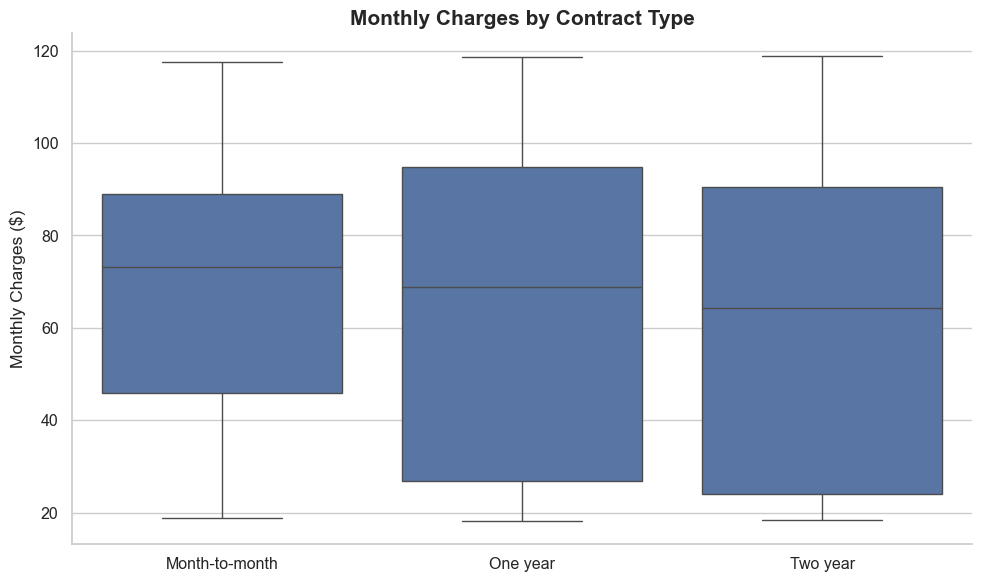

In [109]:
fig, ax = plt.subplots(figsize=(10,6))

sns.boxplot(
    data=telco_churn,
    x="contract",
    y="monthlycharges",
    ax=ax
)

ax.set_title(
    "Monthly Charges by Contract Type",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Monthly Charges ($)")

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Monthly charges vary across contract types, indicating that pricing and contract structure are closely related.

However, despite paying higher monthly charges in some cases, customers with longer-term contracts remain substantially more loyal than month-to-month customers. This suggests that contract commitment plays a more important role in retention than price alone.

### Relationship Between Tenure and Monthly Charges

The following scatter plot illustrates how monthly charges vary throughout the customer lifecycle.

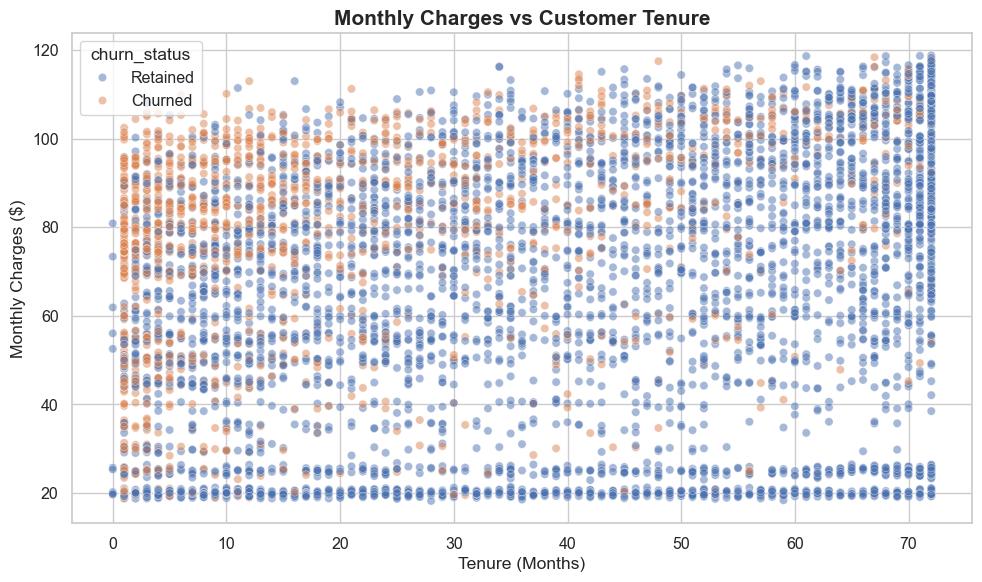

In [110]:
fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(
    data=telco_churn,
    x="tenure",
    y="monthlycharges",
    hue="churn_status",
    alpha=0.5,
    ax=ax
)

ax.set_title(
    "Monthly Charges vs Customer Tenure",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

### Contract and Tenure Summary

Contract duration and customer tenure are the strongest behavioral indicators of churn observed in this analysis.

Key findings include:

- Month-to-month contracts experience the highest churn.
- Long-term contracts dramatically improve retention.
- Customers are most vulnerable during their first year.
- Churn steadily declines as customer tenure increases.
- Early customer engagement and contract conversion initiatives represent the greatest opportunities for improving retention.

These findings are consistent with the SQL analysis and provide a strong foundation for targeted customer retention strategies.

## 5. Service Analysis

Telecommunication providers offer multiple value-added services beyond basic phone and internet connectivity. This section evaluates whether customer adoption of internet services, security features, backup solutions, technical support, and streaming services is associated with customer retention.

The objective is to identify which services appear to reduce churn and which customer groups represent the greatest operational risk.

### Churn by Internet Service

Internet service type is expected to be one of the strongest operational factors influencing customer retention.

In [111]:
internet_churn = summarize_churn_by_category(
    telco_churn,
    "internetservice"
)

internet_churn

,internetservice,customer_count,churned_customers,churn_rate,churn_rate_pct
1,Fiber optic,3096,1297,0.42,41.89
0,DSL,2421,459,0.19,18.96
2,No,1526,113,0.07,7.40


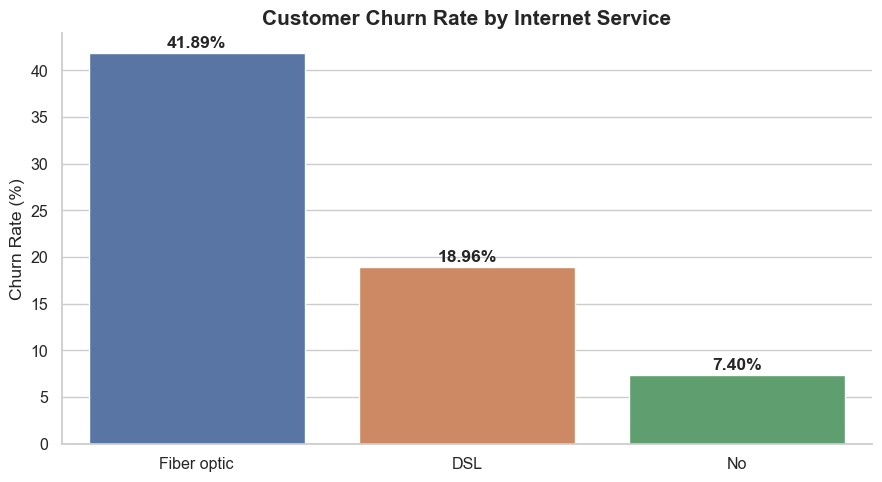

In [112]:
fig, ax = plt.subplots(figsize=(9,5))

sns.barplot(
    data=internet_churn,
    x="internetservice",
    y="churn_rate_pct",
    hue="internetservice",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Rate by Internet Service",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")

for i, row in internet_churn.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["churn_rate_pct"] + 0.5,
        f"{row['churn_rate_pct']:.2f}%",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Internet service type is a major differentiator of customer retention.

Customers using **Fiber Optic** service experience the highest churn rate at approximately **41.89%**, compared with **18.96%** for DSL customers and **7.41%** for customers without internet service.

Although Fiber Optic customers typically subscribe to higher-value plans, they also appear more likely to leave the company. This suggests opportunities to improve pricing, reliability, customer support, or service quality for Fiber Optic customers.

### Churn by Online Security

Online security is evaluated to determine whether customers purchasing additional protection services demonstrate stronger retention.

In [113]:
security_churn = summarize_churn_by_category(
    telco_churn,
    "onlinesecurity"
)

security_churn

,onlinesecurity,customer_count,churned_customers,churn_rate,churn_rate_pct
0,0,5024,1574,0.31,31.33
1,1,2019,295,0.15,14.61


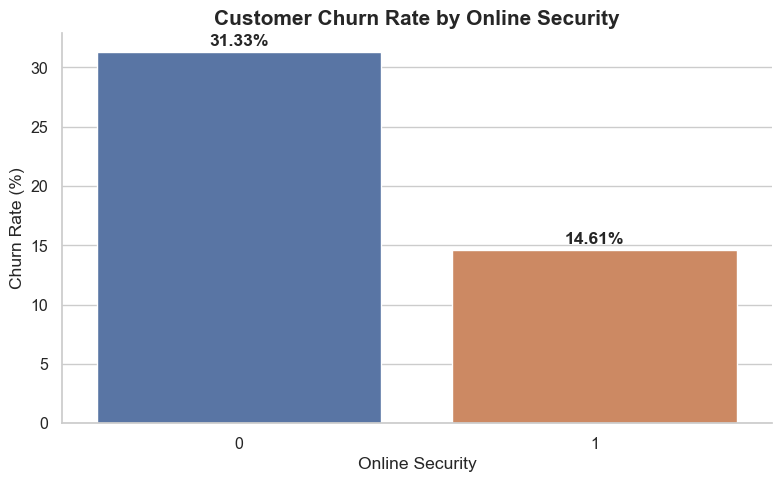

In [114]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=security_churn,
    x="onlinesecurity",
    y="churn_rate_pct",
    hue="onlinesecurity",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Rate by Online Security",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Online Security")
ax.set_ylabel("Churn Rate (%)")

for i,row in security_churn.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["churn_rate_pct"]+0.5,
        f"{row['churn_rate_pct']:.2f}%",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Customers without online security experience a churn rate of approximately **41.77%**, while customers subscribing to online security churn at only **14.61%**.

Online security appears to strengthen customer retention, potentially by increasing perceived value and creating deeper engagement with company services.

### Churn by Technical Support

Technical support is analyzed to determine whether access to customer assistance improves long-term retention.

In [115]:
support_churn = summarize_churn_by_category(
    telco_churn,
    "techsupport"
)

support_churn

,techsupport,customer_count,churned_customers,churn_rate,churn_rate_pct
0,0,4999,1559,0.31,31.19
1,1,2044,310,0.15,15.17


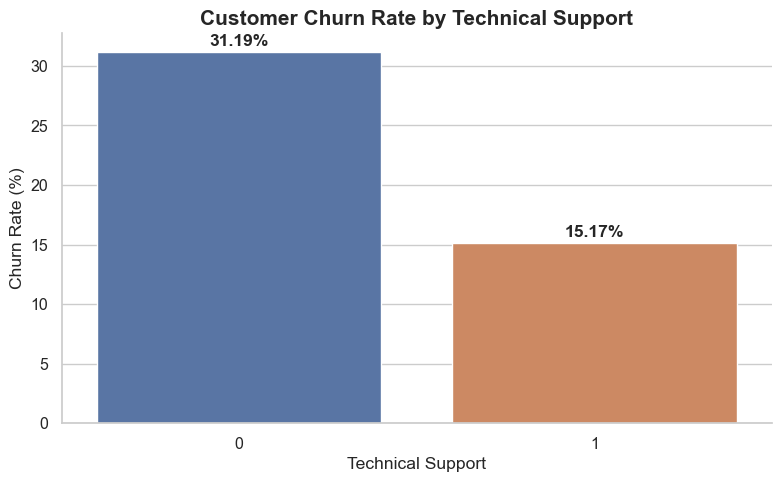

In [116]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=support_churn,
    x="techsupport",
    y="churn_rate_pct",
    hue="techsupport",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Rate by Technical Support",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Technical Support")
ax.set_ylabel("Churn Rate (%)")

for i,row in support_churn.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["churn_rate_pct"]+0.5,
        f"{row['churn_rate_pct']:.2f}%",
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Technical support is one of the strongest service-related predictors of retention.

Customers without technical support experience churn rates exceeding **41%**, while customers receiving technical support churn at approximately **15%**.

These findings suggest that customer support services substantially improve customer loyalty and satisfaction.

Support Services Adoption

In [117]:
support_columns = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport"
]

internet_customers = (
    telco_churn[
        telco_churn["internetservice"] != "No"
    ]
    .copy()
)

internet_customers["support_services"] = (
    internet_customers[support_columns]
    .sum(axis=1)
    .astype(int)
)

support_summary = summarize_churn_by_category(
    internet_customers,
    "support_services"
)

support_summary

,support_services,customer_count,churned_customers,churn_rate,churn_rate_pct
0,0,1267,718,0.57,56.67
1,1,1467,570,0.39,38.85
2,2,1372,326,0.24,23.76
3,3,941,117,0.12,12.43
4,4,470,25,0.05,5.32


In [118]:
telco_churn["support_services"].value_counts().sort_index()

KeyError: 'support_services'

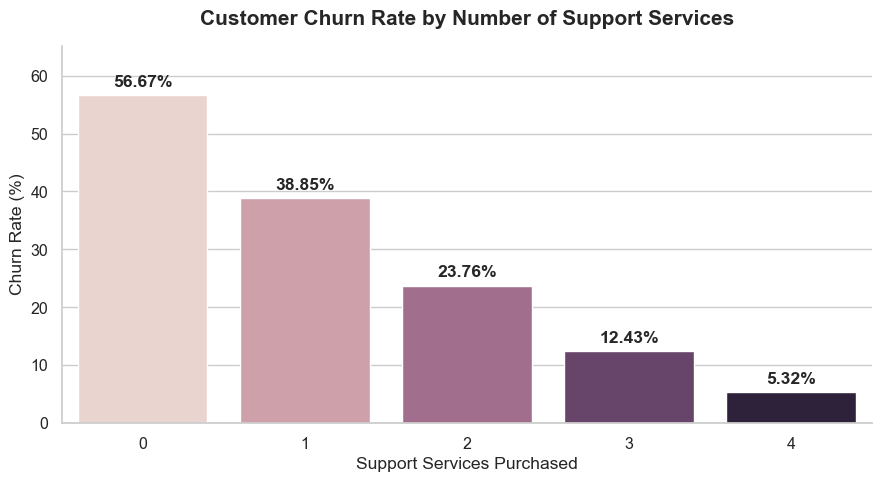

In [ ]:
support_plot = (
    support_summary
    .sort_values("support_services")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=support_plot,
    x="support_services",
    y="churn_rate_pct",
    hue="support_services",
    legend=False,
    ax=ax
)

ax.set_title(
    "Customer Churn Rate by Number of Support Services",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Support Services Purchased")
ax.set_ylabel("Churn Rate (%)")

ax.set_ylim(
    0,
    support_plot["churn_rate_pct"].max() * 1.15
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontweight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Customer churn decreases sharply as customers adopt more support services.

Among internet customers, those with no support services experience the highest churn rate at 56.67%, while customers with all four support services have the lowest churn rate at 5.32%.

The pattern is consistently downward across every service level, indicating that greater support-service adoption is strongly associated with improved customer retention. This suggests that promoting bundled support offerings may help strengthen customer engagement and reduce churn.

Streaming Services (Combined)

In [ ]:
streaming_summary = pd.DataFrame({
    "Streaming TV": telco_churn.groupby("streamingtv")["churn"].mean()*100,
    "Streaming Movies": telco_churn.groupby("streamingmovies")["churn"].mean()*100
}).round(2)

streaming_summary

,Streaming TV,Streaming Movies
0,24.33,24.38
1,30.07,29.94


### Business Insight

Streaming TV and Streaming Movies show relatively small differences in churn across customer groups compared with internet service, online security, and technical support.

While streaming services may contribute to the overall customer experience, they appear to have a weaker relationship with customer retention than support-oriented services. This suggests that investments in customer support, security features, and service quality are likely to have a greater impact on reducing churn than streaming service offerings alone.

### Service Analysis Summary

Service-related features provide some of the strongest operational insights into customer churn.

Key findings include:

- Fiber Optic customers experience substantially higher churn than DSL customers and customers without internet service.
- Customers subscribing to Online Security and Technical Support demonstrate significantly stronger retention.
- Among internet customers, churn decreases consistently as the number of adopted support services increases, falling from 56.67% for customers with no support services to 5.32% for customers using all four.
- Streaming TV and Streaming Movies exhibit relatively small differences in churn compared with security and support services, suggesting they are weaker indicators of customer retention.

Overall, the analysis indicates that customer engagement through support-oriented and value-added services is closely associated with long-term retention. Expanding support-service adoption and improving the experience of high-risk segments, particularly Fiber Optic customers, may help reduce churn and strengthen customer loyalty.

## Financial Analysis

Customer billing characteristics play an important role in understanding churn behavior. This section examines monthly and total customer charges to determine whether pricing patterns differ between retained and churned customers.

The analysis focuses on identifying relationships between customer spending and churn, providing insights into potential pricing, value perception, and customer lifetime value.

In [ ]:
financial_summary = (
    telco_churn
    .groupby("churn_status", observed=False)
    .agg(
        customer_count=("churn", "size"),
        average_monthly_charge=("monthlycharges", "mean"),
        median_monthly_charge=("monthlycharges", "median"),
        average_total_charge=("totalcharges", "mean"),
        median_total_charge=("totalcharges", "median")
    )
    .round(2)
    .reset_index()
)

financial_summary

,churn_status,customer_count,average_monthly_charge,median_monthly_charge,average_total_charge,median_total_charge
0,Churned,1869,74.44,79.65,"1,531.80",703.55
1,Retained,5174,61.27,64.43,"2,549.91","1,679.52"


Monthly Charges Boxplot

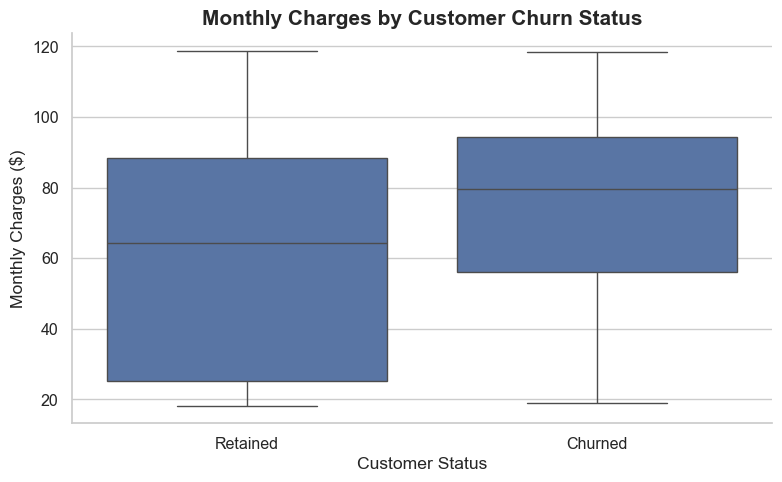

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=telco_churn,
    x="churn_status",
    y="monthlycharges"
)

plt.title(
    "Monthly Charges by Customer Churn Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges ($)")

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Customers who churn generally pay higher monthly charges than retained customers.

This pattern suggests that higher recurring costs may contribute to customer dissatisfaction or encourage customers to seek lower-cost alternatives. Pricing strategies and perceived service value may therefore play an important role in reducing customer churn.

Total Charges Boxplot

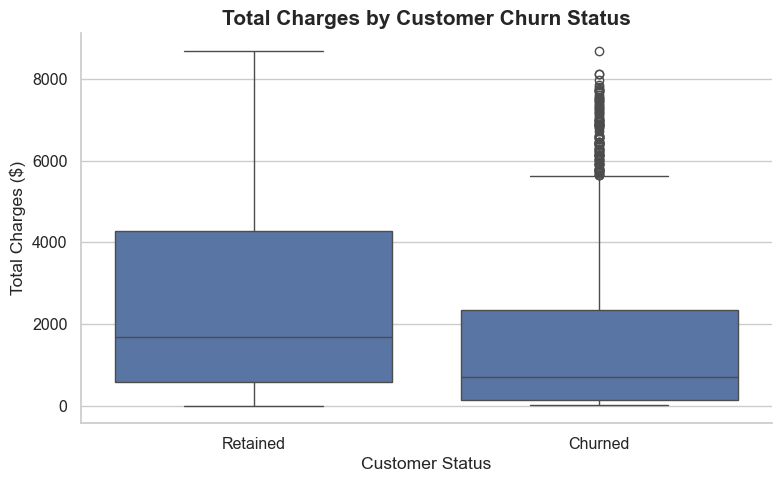

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=telco_churn,
    x="churn_status",
    y="totalcharges"
)

plt.title(
    "Total Charges by Customer Churn Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Customer Status")
plt.ylabel("Total Charges ($)")

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Retained customers accumulate substantially higher total charges than churned customers because they remain with the company for longer periods.

This finding reinforces the importance of customer retention, as longer customer relationships generate greater lifetime value despite churned customers often paying higher monthly charges.

Monthly Charge Distribution

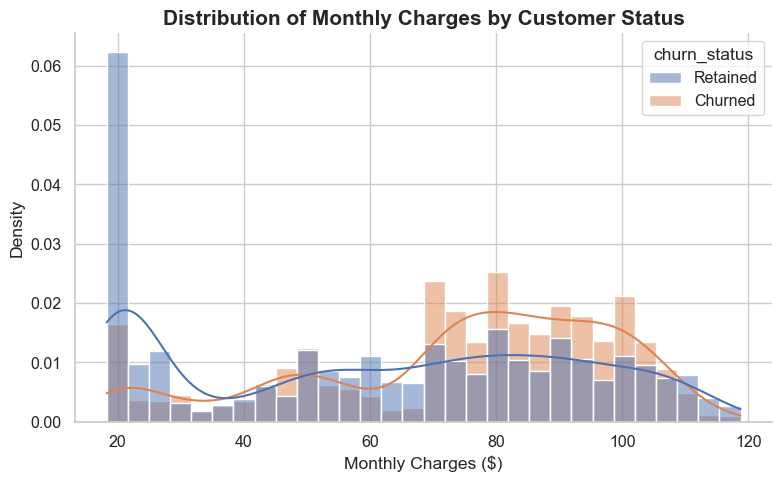

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=telco_churn,
    x="monthlycharges",
    hue="churn_status",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title(
    "Distribution of Monthly Charges by Customer Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")

sns.despine()
plt.tight_layout()
plt.show()

Monthly Charges by Contract

In [ ]:
contract_charge_summary = (
    telco_churn
    .groupby("contract", observed=False)
    .agg(
        average_monthly_charge=("monthlycharges", "mean")
    )
    .round(2)
    .reset_index()
)

contract_charge_summary

,contract,average_monthly_charge
0,Month-to-month,66.40
1,One year,65.05
2,Two year,60.77


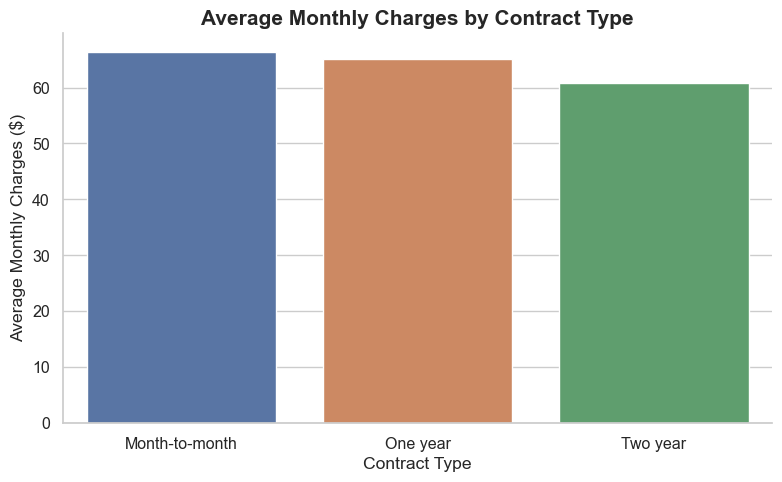

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_charge_summary,
    x="contract",
    y="average_monthly_charge",
    hue="contract",
    legend=False
)

plt.title(
    "Average Monthly Charges by Contract Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Average Monthly Charges ($)")

sns.despine()
plt.tight_layout()
plt.show()

### Business Insight

Average monthly charges are relatively similar across contract types, with only modest differences between month-to-month, one-year, and two-year customers.

Despite these comparable pricing levels, month-to-month customers experience substantially higher churn than customers on longer-term contracts. This suggests that contract commitment, rather than monthly pricing alone, is a much stronger driver of customer retention.

These findings indicate that encouraging customers to transition from month-to-month plans to longer-term contracts may be more effective than focusing solely on pricing adjustments.

### Financial Analysis Summary

Financial characteristics provide additional insight into customer churn behavior.

Key findings include:

- Churned customers pay higher monthly charges on average than retained customers.
- Retained customers accumulate significantly higher total charges due to longer customer lifetimes.
- Monthly pricing contributes to churn risk but should be interpreted alongside contract type and tenure.
- Longer customer relationships generate substantially greater lifetime value for the business.

Overall, the analysis suggests that pricing strategies, customer lifetime value, and contract commitment should all be considered when developing customer retention initiatives.

## Correlation Analysis

Correlation analysis provides a high-level view of the relationships among key numerical variables in the dataset. While correlation does not imply causation, it helps identify features that are positively or negatively associated with customer churn and supports the findings from the earlier exploratory analyses.

In [ ]:
correlation_data = telco_churn[
    [
        "tenure",
        "monthlycharges",
        "totalcharges",
        "seniorcitizen",
        "churn"
    ]
].copy()

correlation_data["support_services"] = (
    telco_churn[
        [
            "onlinesecurity",
            "onlinebackup",
            "deviceprotection",
            "techsupport"
        ]
    ]
    .sum(axis=1)
    .astype(int)
)

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,tenure,monthlycharges,totalcharges,seniorcitizen,churn,support_services
tenure,1.00,0.25,0.83,0.02,-0.35,0.50
monthlycharges,0.25,1.00,0.65,0.22,0.19,0.56
totalcharges,0.83,0.65,1.00,0.10,-0.20,0.68
seniorcitizen,0.02,0.22,0.10,1.00,0.15,0.01
churn,-0.35,0.19,-0.20,0.15,1.00,-0.17
support_services,0.50,0.56,0.68,0.01,-0.17,1.00


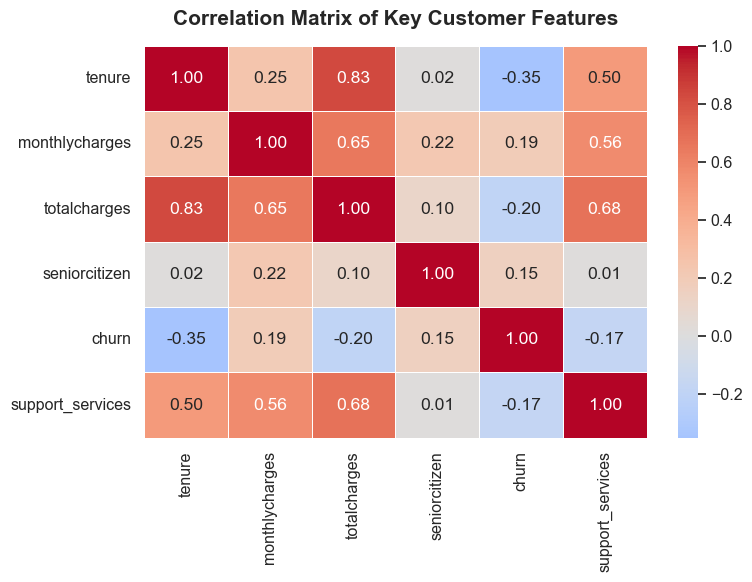

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Key Customer Features",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

### Business Insight

The correlation analysis reinforces several patterns identified throughout the exploratory analysis.

Tenure exhibits the strongest negative relationship with customer churn, indicating that longer-tenured customers are less likely to leave. Monthly charges show a moderate positive association with churn, suggesting that higher recurring costs may increase customer attrition.

Support service adoption is negatively correlated with churn, supporting earlier findings that customers using multiple support services demonstrate stronger retention. Overall, the correlation matrix confirms that customer tenure, pricing, and support-service engagement are among the most influential numerical factors associated with churn.

### Correlation Analysis Summary

The correlation analysis complements the earlier exploratory findings by identifying meaningful relationships among key numerical variables.

Key findings include:

- Customer tenure shows the strongest negative relationship with churn.
- Higher monthly charges are moderately associated with increased churn.
- Total charges are strongly related to tenure, reflecting accumulated customer value over time.
- Support-service adoption is associated with lower churn and stronger customer retention.

Overall, the correlation analysis supports the conclusions drawn from the demographic, contract, service, and financial analyses, providing additional evidence for the primary drivers of customer churn.

# Executive Summary

This exploratory data analysis examined customer demographics, contract characteristics, service adoption, billing behavior, and financial metrics to identify the primary factors associated with customer churn in the IBM Telco Customer Churn dataset.

The analysis found that customer retention is influenced by multiple business factors rather than a single characteristic. Customers on month-to-month contracts, those within their first year of service, Fiber Optic internet subscribers, and customers paying higher monthly charges consistently exhibited elevated churn rates. In contrast, customers with longer contract commitments, longer tenure, and greater adoption of support-oriented services demonstrated substantially stronger retention.

Service adoption emerged as one of the strongest indicators of customer loyalty. Among internet customers, churn decreased consistently as the number of support services increased, falling from **56.67%** for customers with no support services to **5.32%** for customers using all four support services. Online Security and Technical Support were particularly associated with improved customer retention, while Streaming TV and Streaming Movies showed comparatively weaker relationships with churn.

Financial analysis indicated that churned customers generally pay higher monthly charges, whereas retained customers accumulate significantly higher total charges due to longer customer lifetimes. These findings suggest that customer lifetime value is driven primarily by retention rather than short-term revenue.

Overall, the analysis indicates that the greatest opportunities for reducing customer churn lie in encouraging longer-term contract adoption, increasing customer engagement during the early stages of the customer lifecycle, promoting support-service adoption, and improving the experience of high-risk customer segments, particularly Fiber Optic and month-to-month customers.

The insights generated through this exploratory analysis establish a strong foundation for the subsequent statistical analysis, SQL reporting, Power BI dashboard development, and predictive modeling performed in later stages of this project.